# 03 · EDA · 품질 측정

## ★ 이 노트북이 하지 않는 것

**흐리거나 어두운 이미지를 학습에서 빼지 않는다.**

> PLAN §3.4 규칙 2 — *모델이 측정할 수 있는 오염은 선제 차단하지 않는다. 측정하고 대응한다.*

`quality_status='drop'` 은 **파일이 실제로 깨진 경우에만** 붙는다.
흐림·어두움·저해상도는 `review` 로 **표시만** 하고 학습에는 그대로 들어간다.
baseline 이 그 영향을 실제로 보여준 뒤에 대응한다.

기존 프로젝트는 이 순서를 뒤집어 감사 코드 4,325줄을 쓰고 실제 학습은 7분이었다
(`RESTART_HERE.md` 3절).

## ★ 수동 검수 상한 100건

> PLAN §3.4 규칙 1 — *모델이 없는 동안 수동 검수는 누적 100건 상한.*

자동 플래그는 그보다 많을 수 있으나 **사람이 보는 큐는 100건**으로 자른다.
상한을 늘리려면 baseline 결과로 필요성을 입증해야 한다.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from banggoot import imagestats
from banggoot.paths import ENCODING, load_paths

pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid")

crops = pd.read_csv(load_paths().artifact("metadata") / "crops.csv",
                    encoding=ENCODING, low_memory=False)
print(f"crops.csv {len(crops):,} x {len(crops.columns)}")
print(crops.groupby(["lane", "mode"]).size().to_string())

crops.csv 13,264 x 32
lane         mode        
ablation     bbox_crop       4405
baseline     identity        4948
             polygon_crop    3691
lineage_a7   bbox_crop        205
review_only  polygon_crop      15


## 1. 품질 측정

13,264 샘플 전량. crop 은 `artifacts/crops/`, identity 는 기존 저장소 원본을 읽는다.
I/O 바운드라 스레드로 병렬화한다.

In [2]:
stats = imagestats.measure(crops)

print(f"측정 {len(stats):,} | readable {int(stats.readable.sum()):,} "
      f"| unreadable {int((~stats.readable).sum()):,}")
stats.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)

quality:   0%|          | 0/13264 [00:00<?, ?it/s]

측정 13,264 | readable 13,264 | unreadable 0


,count,mean,std,min,50%,max
width,13264.0,418.21,256.64,96.00,352.00,3096.00
height,13264.0,413.31,244.34,96.00,352.00,3096.00
aspect_ratio,13264.0,1.01,0.14,0.45,1.00,2.99
megapixels,13264.0,0.23,0.29,0.01,0.12,9.59
mean_brightness,13264.0,151.50,29.23,15.45,153.20,250.98
contrast_std,13264.0,29.45,18.03,1.56,25.55,106.16
saturation,13264.0,25.65,23.25,0.00,18.54,221.26
blur_var,13264.0,689.86,1220.23,0.62,204.99,14731.03
dark_frac,13264.0,0.01,0.05,0.00,0.00,0.78
bright_frac,13264.0,0.03,0.09,0.00,0.00,0.98


## 2. 데이터셋별 분포

절대 임계값을 쓰지 않는 이유가 여기서 드러난다. 227×227 kaggle 패치와 1080px AIHub crop 이
같은 표에 있어 "blur_var < 100 은 흐림" 같은 규칙은 의미가 없다.

In [3]:
df = crops.merge(stats, on="sample_id", how="left", validate="1:1")

cols = ["width", "height", "megapixels", "blur_var",
        "mean_brightness", "contrast_std", "saturation"]
df.groupby("dataset")[cols].median().round(1)

,width,height,megapixels,blur_var,mean_brightness,contrast_std,saturation
dataset,,,,,,,
aihub_567,350.0,350.0,0.1,969.6,150.9,42.0,27.8
dacon_wallpaper,617.0,636.0,0.4,164.7,152.8,19.8,14.0
kaggle_cracks,227.0,227.0,0.1,80.4,164.5,30.0,22.4
roboflow_house_defect,246.0,246.0,0.1,109.7,147.9,18.8,16.2
roboflow_wall_defects,341.0,341.0,0.1,552.8,161.2,33.7,27.7
roboflow_wallpaper_kr,240.0,240.0,0.1,129.0,155.1,16.3,13.8


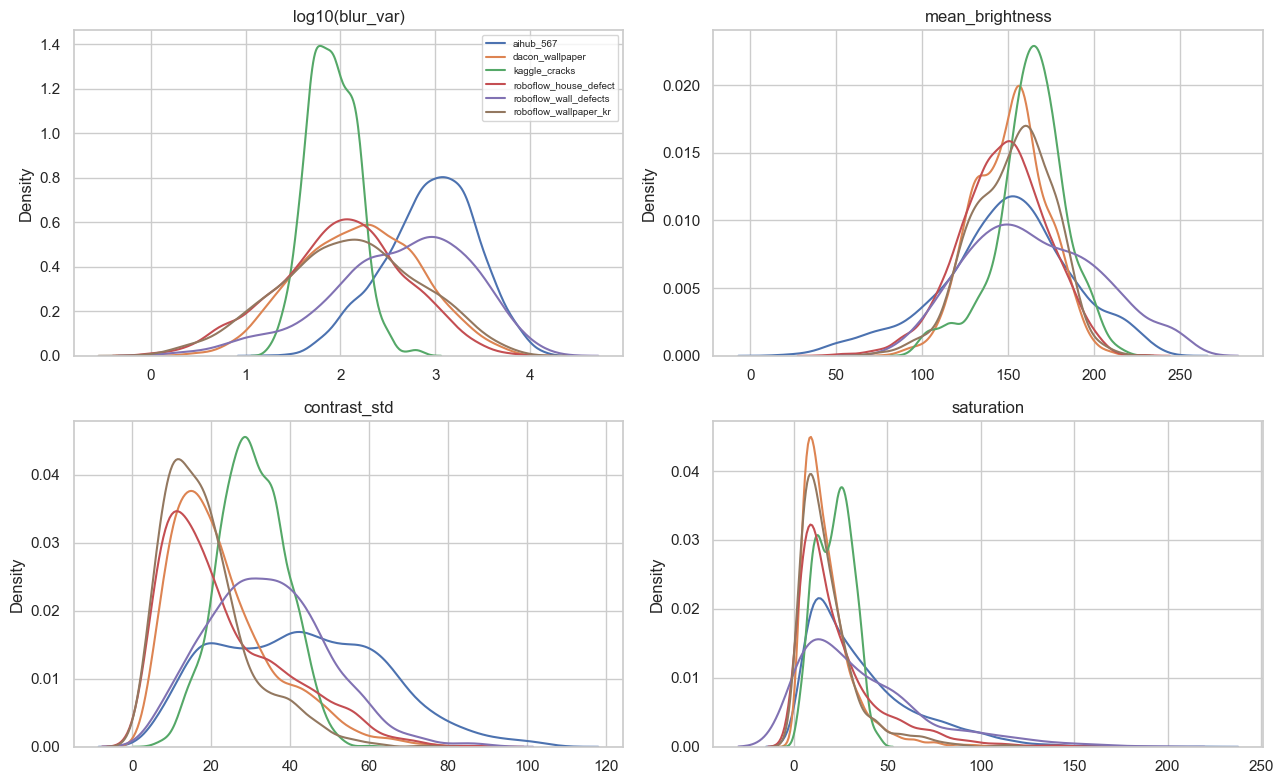

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), ["blur_var", "mean_brightness", "contrast_std", "saturation"]):
    for ds, g in df.groupby("dataset"):
        v = g[col].dropna()
        if col == "blur_var":
            v = np.log10(v.clip(lower=1))
        sns.kdeplot(v, ax=ax, label=ds, fill=False, warn_singular=False)
    ax.set_title(f"log10({col})" if col == "blur_var" else col)
    ax.set_xlabel("")
axes[0, 0].legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

## 3. ★ 출처 편향 — 요약 통계만으로 데이터셋이 갈리는가

PLAN §3.2 최우선 위험(P1)에 대한 **정량적 사전 증거**다.
이미지 전체를 보는 것이 아니라 **요약 통계 몇 개만** 사용한다.

### feature tier 를 나누는 이유

`megapixels` 와 `aspect_ratio` 는 **모델이 보지 못하는 정보**다.
학습은 224×224 resize 후에 이뤄지므로 원본 크기·종횡비는 소실된다.
이 둘을 포함한 수치는 **upper bound** 이지 모델이 쓸 수 있는 shortcut 크기가 아니다.

| tier | 포함 | 의미 |
| --- | --- | --- |
| `full` | 8개 (크기·비율 포함) | upper bound |
| `no_size` | 6개 (크기·비율 제외) | 모델 가시 정보에 근접 |
| `photometric` | 5개 (`blur_var` 도 제외 — 해상도 의존) | 가장 보수적 |
| `resized_224` | 224 resize 후 재측정 | **모델이 실제로 보는 것** |

### 교차검증

일반 KFold 는 같은 `split_component_id` 의 crop 이 train/test 양쪽에 들어가
정확도를 부풀린다. **`StratifiedGroupKFold(groups=split_component_id)`** 를 쓴다.

### majority baseline 은 따로 읽는다

- 출처 accuracy majority = **0.4272**
- L1 macro F1 majority = **0.0993** (6-class, 다수 클래스만 맞추는 경우)

두 수치는 스케일이 다르므로 직접 비교하지 않고 각각의 lift 로 본다.


In [5]:
from banggoot import sourcebias

base = df[df.lane.eq("baseline") & df.readable.fillna(False)].copy()
print(f"baseline 샘플 {len(base):,}")

# 모델 입력과 같은 224 resize 후 재측정
resized = sourcebias.measure_resized(base)
probe_table = sourcebias.run_all(base, resized)
display(probe_table)

baseline 샘플 8,639


resized-224:   0%|          | 0/8639 [00:00<?, ?it/s]

,tier,target,scoring,n_features,n_samples,mean,std,majority,lift_over_majority
0,full,dataset,accuracy,8,8639,0.9995,0.0002,0.4272,0.5723
1,full,unified_label,f1_macro,8,8639,0.6943,0.0293,0.0993,0.5950
2,no_size,dataset,accuracy,6,8639,0.8270,0.0273,0.4272,0.3997
3,no_size,unified_label,f1_macro,6,8639,0.3178,0.0181,0.0993,0.2185
4,photometric,dataset,accuracy,5,8639,0.7744,0.0222,0.4272,0.3471
5,photometric,unified_label,f1_macro,5,8639,0.2932,0.0209,0.0993,0.1939
6,resized_224,dataset,accuracy,6,8639,0.8335,0.0253,0.4272,0.4063
7,resized_224,unified_label,f1_macro,6,8639,0.3629,0.0299,0.0993,0.2636


In [6]:
print(sourcebias.interpretation(probe_table))

해석 규율:

  full tier (0.9995) 는 megapixels / aspect_ratio 를 포함하므로
  **upper bound** 다. 모델은 224 resize 후 학습하므로 원본 크기·종횡비를 보지 못한다.
  이 수치를 '모델이 쓸 수 있는 shortcut 크기'로 인용하면 안 된다.

  크기·비율 제외                         출처 accuracy 0.8270
  photometric only                 출처 accuracy 0.7744
  224 resize 후 (모델 입력과 동일)         출처 accuracy 0.8335

  어느 tier 에서도 출처가 majority 를 크게 상회하면 shortcut 이 **가능하다**.
  실제로 사용했는지는 노트북 08 의 픽셀 기반 source-ID probe 와
  leave-one-source-out (crack / breakage 만 가능) 으로 측정한다.


### 클래스와 출처의 결합

`crack` 은 kaggle+aihub, `breakage` 는 dacon+aihub 로 2개 출처가 있지만
나머지 4개는 DACON 단일이다. 단일 출처 클래스는 위 두 수치를 분리할 수 없다.

In [7]:
ct = pd.crosstab(base.unified_label, base.dataset, margins=True)
display(ct)

for label in ct.index.drop("All"):
    srcs = [c for c in ct.columns if c != "All" and ct.loc[label, c] > 0]
    tag = "LOSO 가능" if len(srcs) >= 2 else "단일 출처 — 교차검증 불가"
    print(f"  {label:18s} 출처 {len(srcs)}개 {srcs}  {tag}")

dataset,aihub_567,dacon_wallpaper,kaggle_cracks,All
unified_label,,,,
breakage,1848,1817,0,3665
crack,1843,0,1500,3343
finish_damage,0,799,0,799
lifting,0,76,0,76
mold,0,144,0,144
stain_corrosion,0,612,0,612
All,3691,3448,1500,8639


  breakage           출처 2개 ['aihub_567', 'dacon_wallpaper']  LOSO 가능
  crack              출처 2개 ['aihub_567', 'kaggle_cracks']  LOSO 가능
  finish_damage      출처 1개 ['dacon_wallpaper']  단일 출처 — 교차검증 불가
  lifting            출처 1개 ['dacon_wallpaper']  단일 출처 — 교차검증 불가
  mold               출처 1개 ['dacon_wallpaper']  단일 출처 — 교차검증 불가
  stain_corrosion    출처 1개 ['dacon_wallpaper']  단일 출처 — 교차검증 불가


## 4. 클래스 불균형

unified_label
breakage           3665
crack              3343
finish_damage       799
stain_corrosion     612
mold                144
lifting              76

최대/최소 비율: 48.2배  (breakage 3,665 vs lifting 76)


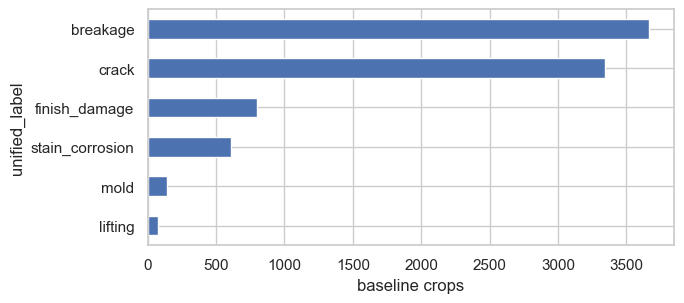

In [8]:
vc = base.unified_label.value_counts()
print(vc.to_string())
print(f"\n최대/최소 비율: {vc.max() / vc.min():.1f}배  ({vc.idxmax()} {vc.max():,} vs {vc.idxmin()} {vc.min()})")

ax = vc.sort_values().plot.barh(figsize=(7, 3.2))
ax.set_xlabel("baseline crops")
plt.tight_layout(); plt.show()

## 5. quality_status 확정

임계값은 상수가 아니라 **데이터셋별 하위 1% 분위**에서 잡는다.

- `drop` — 읽히지 않는 파일만
- `review` — 이상치 + 승계된 `legacy_annotation_error`. **학습은 계속 들어간다**
- `keep` — 나머지

In [9]:
q = imagestats.assign_quality(crops, stats)

print(q.quality_status.value_counts().to_string())
print()
flags = q.loc[q.quality_flags.fillna("").ne(""), "quality_flags"].str.split(";").explode()
print(flags.value_counts().to_string())

quality_status
keep      12747
review      517

quality_flags
washed_out      152
blur            135
low_contrast    135
dark            134


In [10]:
print("규칙 2 확인 — review 가 학습을 막지 않는가")
chk = q[q.baseline_eligible]
print(chk.groupby(["quality_status", "trainable"]).size().to_string())
print(f"\nbaseline 중 학습 가능: {int(chk.trainable.sum()):,} / {len(chk):,}")
print(f"학습에서 빠진 것     : {int((~chk.trainable).sum()):,}  (drop 뿐이어야 함)")
print(chk[~chk.trainable].quality_status.value_counts().to_string() or "  (없음)")

규칙 2 확인 — review 가 학습을 막지 않는가
quality_status  trainable
keep            True         8324
review          True          315

baseline 중 학습 가능: 8,639 / 8,639
학습에서 빠진 것     : 0  (drop 뿐이어야 함)
Series([], )


## 6. 수동 검수 큐 — 상한 100건

클래스·lane 을 고르게 섞어 한 클래스만 보게 되는 것을 막는다.
`human_verdict` / `human_note` 는 **비워서** 내보낸다. 사람이 채운다.

In [11]:
queue = imagestats.build_review_queue(q)

print(f"자동 review 플래그 : {int(q.quality_status.eq('review').sum()):,}")
print(f"사람 검수 큐       : {len(queue)}  (상한 {imagestats.MANUAL_REVIEW_CAP})")
print()
display(pd.crosstab(queue.lane, queue.unified_label, margins=True))

자동 review 플래그 : 517
사람 검수 큐       : 100  (상한 100)



unified_label,breakage,crack,finish_damage,lifting,moisture_leak,mold,stain_corrosion,All
lane,,,,,,,,
ablation,12,6,6,1,0,6,5,36
baseline,18,15,6,1,0,1,6,47
lineage_a7,0,0,0,0,6,0,0,6
review_only,5,6,0,0,0,0,0,11
All,35,27,12,2,6,7,11,100


## 7. gate

- 수동 검수 큐 ≤ 100 (PLAN §3.4 규칙 1)
- **읽히는데 `drop` 된 샘플 0건** (규칙 2)
- **`review` 가 학습을 막는 샘플 0건** (규칙 2)
- `legacy_annotation_error` 는 여전히 `review`
- `sample_id` 유일

In [12]:
imagestats.verify(q, queue)
print("gate 통과")

out, qout = imagestats.save(q, queue)
print("saved:", out.name, f"({len(q):,} x {len(q.columns)})")
print("saved:", qout.name, f"({len(queue)} rows)")
print("\n다음: 04_build_splits")

gate 통과


saved: crops_quality.csv (13,264 x 46)
saved: 03_quality_queue.csv (100 rows)

다음: 04_build_splits
